### **Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [2]:
# loading dataset 

df = pd.read_csv('cars_hw.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    str  
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(5), str(7)
memory usage: 91.6 KB


In [3]:
df.describe()

,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,Price
count,976.000000,976.000000,976.000000,976.000000,9.760000e+02
mean,488.500000,2016.963115,41571.195697,5.095287,7.410195e+05
std,281.891232,2.818742,24390.995134,0.446224,3.673234e+05
min,1.000000,2011.000000,1117.000000,4.000000,1.880000e+05
25%,244.750000,2015.000000,22676.750000,5.000000,4.757500e+05
50%,488.500000,2017.000000,37570.500000,5.000000,6.665000e+05
75%,732.250000,2019.000000,57421.250000,5.000000,8.830000e+05
max,976.000000,2022.000000,99495.000000,8.000000,2.941000e+06


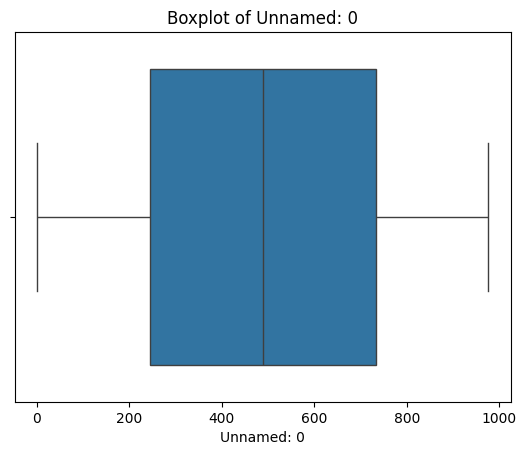

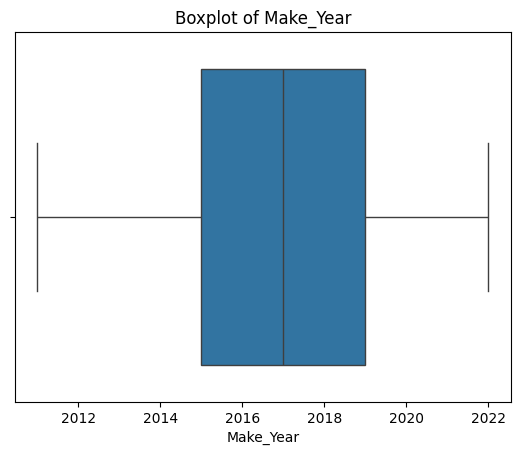

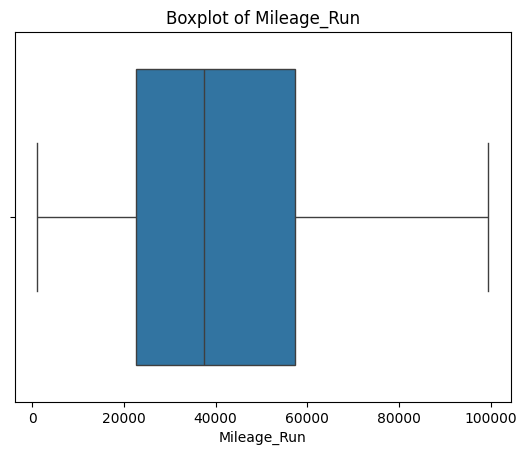

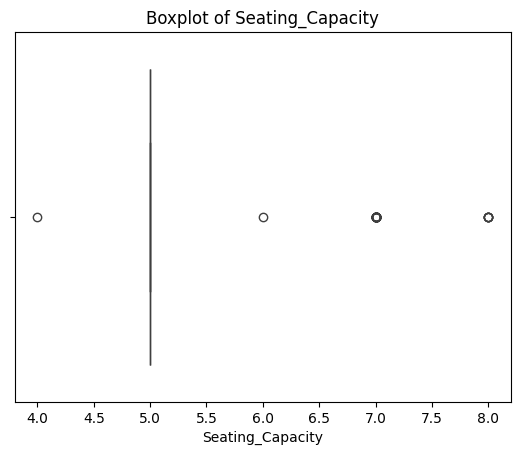

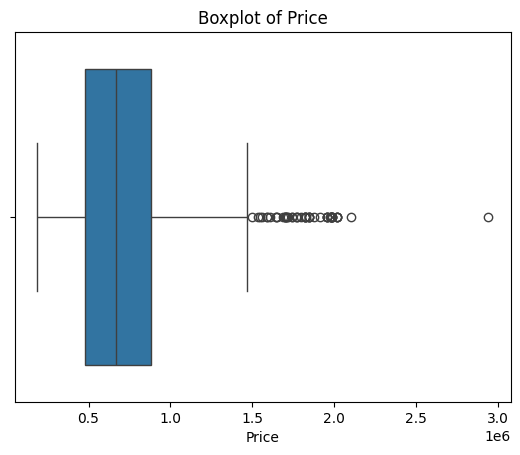

In [4]:
# explore the distribution of numeric features using boxplots

num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

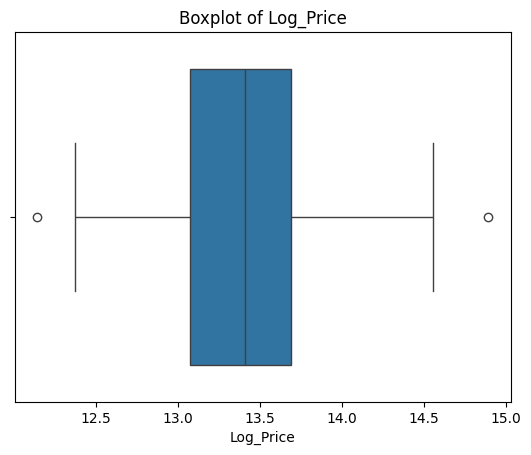

In [5]:
# apply log transformation to the target variable to reduce skewness
df['Log_Price'] = np.log1p(df['Price'])
sns.boxplot(x=df['Log_Price'])
plt.title('Boxplot of Log_Price')
plt.show()

Price Summary Statistics:
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


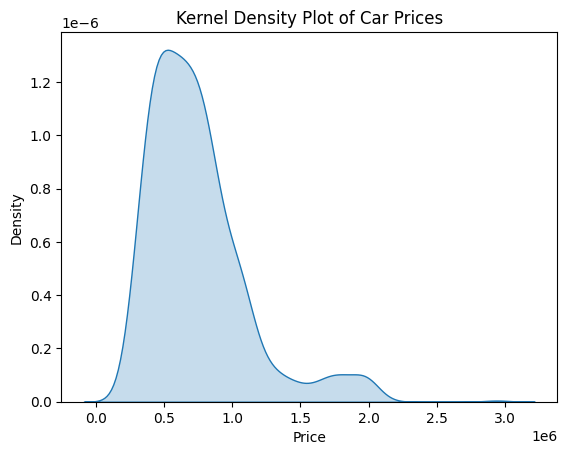

Top 5 Most Expensive Brands (Mean):
           count          mean           std        min        25%        50%  \
Make                                                                            
MG Motors   35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0  1848000.0   
Kia          8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0  1628500.0   
Jeep         4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0  1529500.0   
Skoda        5.0  1.136000e+06  1.070175e+06   436000.0   466000.0   538000.0   
Mahindra    18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0  1094500.0   

                 75%        max  
Make                             
MG Motors  1978000.0  2019000.0  
Kia        1705750.0  1741000.0  
Jeep       1581500.0  1649000.0  
Skoda      1299000.0  2941000.0  
Mahindra   1157000.0  1465000.0  


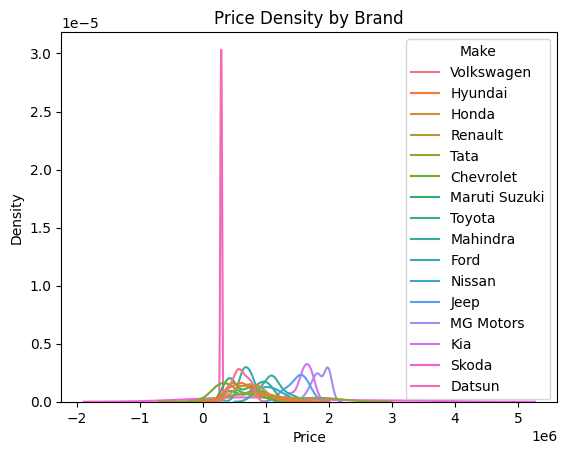

In [6]:
# summary of price
print("Price Summary Statistics:")
print(df['Price'].describe())

sns.kdeplot(df['Price'], fill=True)
plt.title('Kernel Density Plot of Car Prices')
plt.show()

# price by make of car
make_summary = df.groupby('Make')['Price'].describe().sort_values('mean', ascending=False)
print("Top 5 Most Expensive Brands (Mean):")
print(make_summary.head())

sns.kdeplot(data=df, x='Price', hue='Make', common_norm=False)
plt.title('Price Density by Brand')
plt.show()

The most expesive brand is MG Motors. 
In general, most cars fall between $475,000 and $883,000

In [7]:
# prepare data for modeling
X = df.drop(['Price', 'Log_Price'], axis=1)
y = df['Log_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

In [8]:
# modeling function
def evaluate(y_true, y_pred, label=""):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label} R2: {r2}, RMSE: {rmse}")
    return r2, rmse

In [9]:
# model with only numeric features
num_cols = ['Seating_Capacity', 'Make_Year', 'Mileage_Run']
reg_num = LinearRegression().fit(X_train[num_cols], y_train)
preds_num = reg_num.predict(X_test[num_cols])
evaluate(y_test, preds_num, "Model 1 (Numeric Only)")

Model 1 (Numeric Only) R2: 0.33948272766418386, RMSE: 0.3420745734611685


(0.33948272766418386, np.float64(0.3420745734611685))

In [10]:
# model with only categorical features
X_cat = pd.get_dummies(X.select_dtypes(include=['str']), drop_first=True)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_cat, y, test_size=0.2, random_state=40)
reg_cat = LinearRegression().fit(X_c_train, y_c_train)
preds_cat = reg_cat.predict(X_c_test)
evaluate(y_test, preds_cat, "Model 2 (Categorical Only)")

Model 2 (Categorical Only) R2: 0.5956709385944148, RMSE: 0.2676370187361334


(0.5956709385944148, np.float64(0.2676370187361334))

The best model of the two was the one with the one-hot-encoded features.

In [11]:
# model with both numeric and categorical features
X_joint = pd.concat([X[num_cols], X_cat], axis=1)
X_j_train, X_j_test, y_j_train, y_j_test = train_test_split(X_joint, y, test_size=0.2, random_state=40)
reg_joint = LinearRegression().fit(X_j_train, y_j_train)
preds_joint = reg_joint.predict(X_j_test)
evaluate(y_test, preds_joint, "Model 3 (Joint)")

Model 3 (Joint) R2: 0.7728523826715488, RMSE: 0.20060086321958875


(0.7728523826715488, np.float64(0.20060086321958875))

The joint model performs better than both by explaining about 8% more variance in the price than the previous best model.

In [12]:
# adding polynomial features to the numeric variables in the joint model
for d in range(1, 6):
    poly = PolynomialFeatures(degree=d)
    X_train_num_poly = poly.fit_transform(X_j_train[num_cols])
    X_test_num_poly = poly.transform(X_j_test[num_cols])

    X_train_cat = X_j_train.drop(columns=num_cols).values
    X_test_cat = X_j_test.drop(columns=num_cols).values

    X_full_train = np.hstack([X_train_num_poly, X_train_cat])
    X_full_test = np.hstack([X_test_num_poly, X_test_cat])
    
    m = LinearRegression().fit(X_full_train, y_j_train)
    p = m.predict(X_full_test)
    r2_p = r2_score(y_j_test, p)
    rseme_p = np.sqrt(mean_squared_error(y_j_test, p))
    print(f"Degree {d} R2: {r2_p}, RSME: {rseme_p}")
    if r2_p < 0:
        print(f"R2 went negative at degree {d}")


Degree 1 R2: 0.7728523826721196, RSME: 0.20060086321933668
Degree 2 R2: 0.7719420494141256, RSME: 0.20100243256291608
Degree 3 R2: 0.38978155890934585, RSME: 0.3287920959948607
Degree 4 R2: 0.3807698460279956, RSME: 0.3312110008292988
Degree 5 R2: 0.371565347410885, RSME: 0.3336635506362574


As the degree is increased, R2 is decreasing and the RSME is increasing which indicates the model is getting worse rather than improving with the addition of polynomial features.   
The R2 also never went negative on the test set.
The best model has a degree of 1, and its R2 = 0.77 and its RSME = 0.2006. It is the same as the model before because no polynomial features have been added.

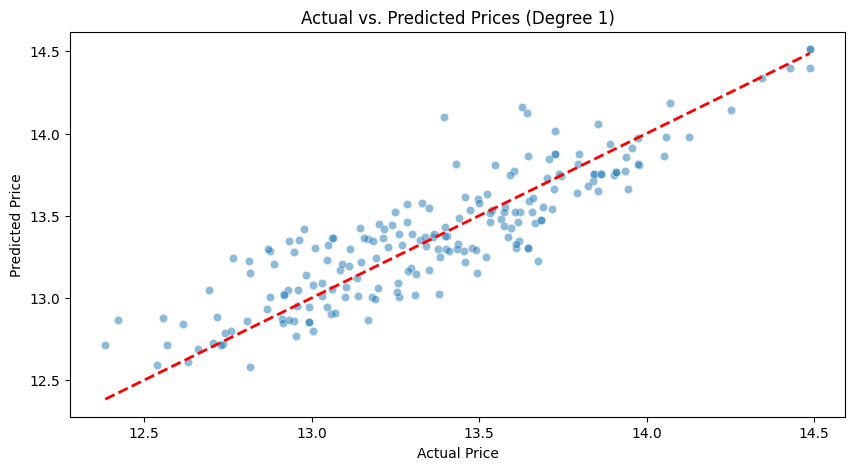

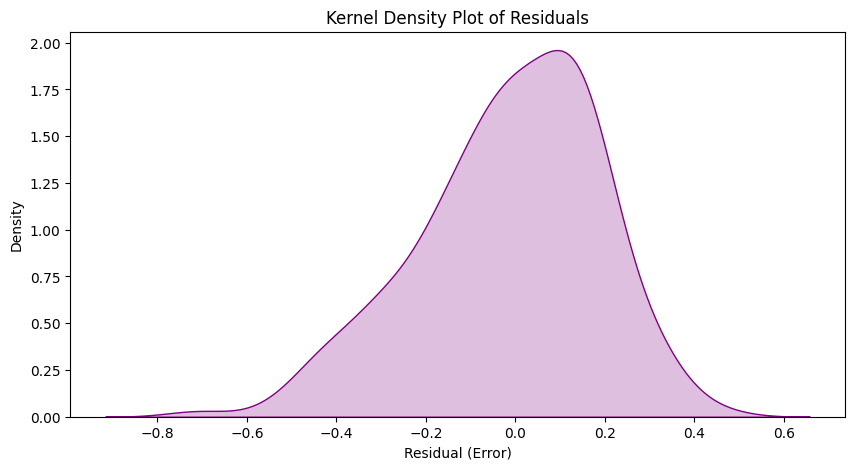

In [18]:
# model with degree 1 



best_model = LinearRegression().fit(X_j_train, y_j_train)
y_preds = best_model.predict(X_j_test)
residuals = y_j_test - y_preds

# Plot Predicted vs. True Values
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_j_test, y=y_preds, alpha=0.5)
plt.plot([y_j_test.min(), y_j_test.max()], [y_j_test.min(), y_j_test.max()], 
         color='red', lw=2, linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Prices (Degree 1)')
plt.show()

# Residual Kernel Density Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(residuals, fill=True, color="purple")
# plt.axvline(0, color='red', linestyle='--')
plt.title('Kernel Density Plot of Residuals')
plt.xlabel('Residual (Error)')
plt.show()

The values roughly follow the line produced by the model, so it captures the overall trend well enough.

The residuals are also in a bell shape but not fully centered at zero indicating the errors are normally distributed but there may be a small systematic bias or the model may be missing a relevant feature causing it to miss the full underlying relationship. 

Overall, the model handles the features together well and the polynomial features help to capture the prices better as well through the nonlinear relationship.

However, it is harder for the linear model to deal subjective values such as a cars color or its maintence which is not present in the dataset. This type of model also can struggle with outlighers which will skew it one way or the other if they are not dealt with.